# Лабораторная работа №1

## 1) Загрузка данных (Отцы и дети)

In [1]:

import re
from collections import Counter
import requests

URL = "http://az.lib.ru/t/turgenew_i_s/text_0040.shtml"

raw = requests.get(URL, timeout=30).text

TAG_RE = re.compile(r"<[^>]+>")
LATIN_RE = re.compile(r"[A-Za-z]+")
ENT_RE = re.compile(r"[&;]+")

raw = TAG_RE.sub("", raw)
raw = LATIN_RE.sub("", raw)
raw = ENT_RE.sub("", raw)

start_position_text = "Посвящается памяти Виссариона Григорьевича Белинского"
end_position_text = "они говорят также о вечном примирении и о жизни бесконечной"

start_idx = raw.find(start_position_text)
end_idx = raw.find(end_position_text)
text = raw
if start_idx != -1:
    text = raw[start_idx:]
    text = text.split("\n", 1)[1] if "\n" in text else text
if end_idx != -1 and end_idx > 0:
    text = text[:end_idx]

print("Длина текста (символов):", len(text))
print(text[:4000])


Длина текста (символов): 358615







-- Что, Петр, не видать еще? -- спрашивал 20-го мая 1859 года, выходя без шапки на низкое крылечко постоялого двора на *** шоссе, барин лет сорока с небольшим, в запыленном пальто и клетчатых панталонах, у своего слуги, молодого и щекастого малого с беловатым пухом на подбородке и маленькими тусклыми глазенками.
Слуга, в котором все: и бирюзовая сережка в ухе, и напомаженные разноцветные волосы, и учтивые телодвижения, словом, все изобличало человека новейшего, усовершенствованного поколения, посмотрел снисходительно вдоль дороги и ответствовал: "Никак нет-с, не видать".
-- Не видать? -- повторил барин.
-- Не видать, -- вторично ответствовал слуга.
Барин вздохнул и присел на скамеечку. Познакомим с ним читателя, пока он сидит, подогнувши под себя ножки и задумчиво поглядывая кругом.
Зовут его Николаем Петровичем Кирсановым. У него в пятнадцати верстах от постоялого дворика хорошее имение в двести душ, или, как он выражается с тех пор, как размежев

## 2) Токенизация, types/tokens, частоты

In [2]:

# Простая токенизация для частот: слова из латинских букв + апострофы
tokens = re.findall(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?", text.lower())
cnt = Counter(tokens)

N_tokens = sum(cnt.values())  # tokens = все употребления
V_types = len(cnt)            # types  = уникальные слова

print(f"Tokens (всего словоупотреблений): {N_tokens:,}")
print(f"Types  (уникальных слов):        {V_types:,}")

# Топ-20
top20 = cnt.most_common(20)
top20[:10]


Tokens (всего словоупотреблений): 54,334
Types  (уникальных слов):        13,104


[('и', 2062),
 ('не', 1339),
 ('в', 1197),
 ('он', 885),
 ('что', 804),
 ('с', 784),
 ('я', 783),
 ('на', 776),
 ('а', 508),
 ('как', 440)]

## 3.1) Zipf: rank–frequency (log–log) + топ-20 + длинный хвост ≤ 3

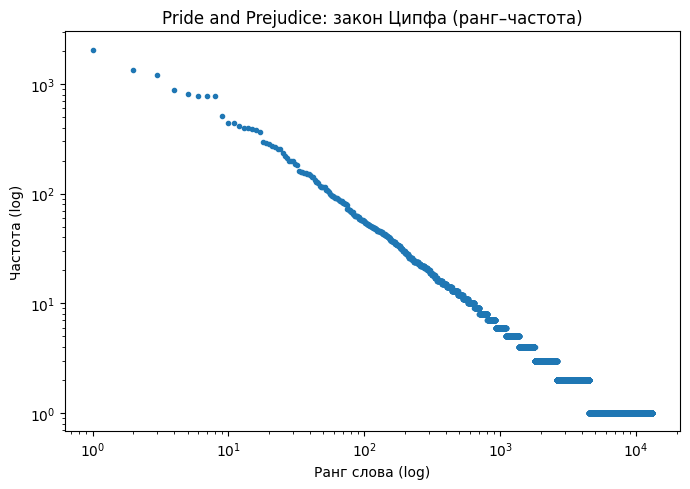

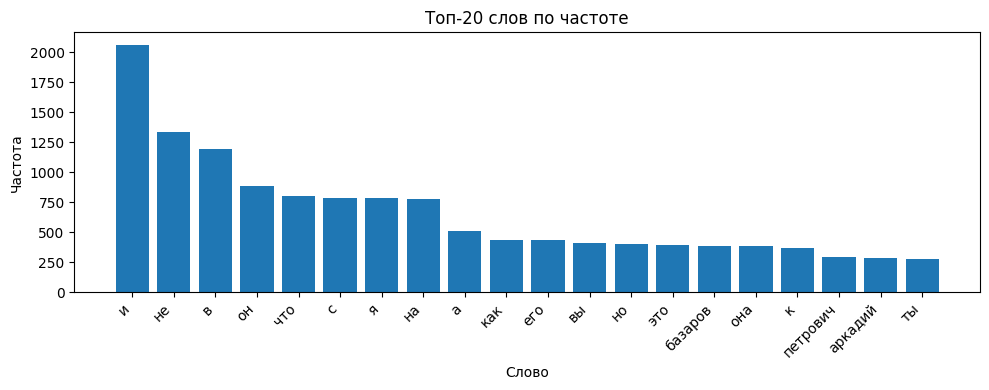

Хвост (c<=3): 11315 типов = 86.3% словаря
Хвост (c<=3): 14870 токенов = 27.4% текста


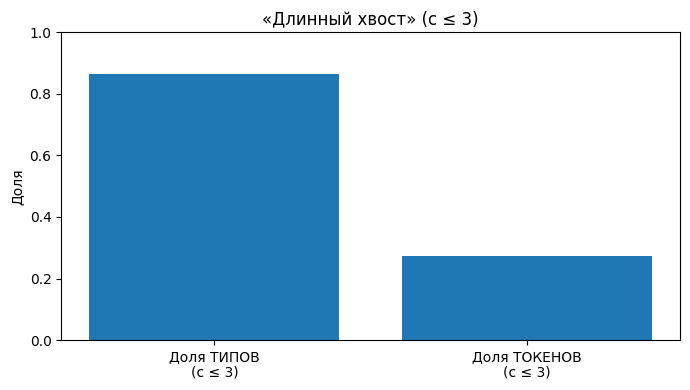

['вдвое',
 'обливала',
 'бабочки',
 'гостили',
 'солнечные',
 'полверсты',
 'лестницей',
 'номер',
 'вареньем',
 'сей']

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Zipf данные
freqs_sorted = np.array(sorted(cnt.values(), reverse=True))
ranks = np.arange(1, len(freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
plt.loglog(ranks, freqs_sorted, marker=".", linestyle="none")
plt.title("Pride and Prejudice: закон Ципфа (ранг–частота)")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

# 3.2 Топ-20
df_top20 = pd.DataFrame(top20, columns=["word","count"])
plt.figure(figsize=(10,4))
plt.bar(df_top20["word"], df_top20["count"])
plt.title("Топ-20 слов по частоте")
plt.xlabel("Слово")
plt.ylabel("Частота")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3.3 Длинный хвост: <= 3
tail_words = [w for w, c in cnt.items() if c <= 3]
tail_types = len(tail_words)
tail_tokens = sum(cnt[w] for w in tail_words)

print(f"Хвост (c<=3): {tail_types} типов = {tail_types/V_types:.1%} словаря")
print(f"Хвост (c<=3): {tail_tokens} токенов = {tail_tokens/N_tokens:.1%} текста")

plt.figure(figsize=(7,4))
plt.bar(["Доля ТИПОВ\n(c ≤ 3)", "Доля ТОКЕНОВ\n(c ≤ 3)"],
        [tail_types/V_types, tail_tokens/N_tokens])
plt.ylim(0, 1)
plt.title("«Длинный хвост» (c ≤ 3)")
plt.ylabel("Доля")
plt.tight_layout()
plt.show()

# 3.4 (Опционально) 10 случайных hapax (c=1)
hapax = [w for w, c in cnt.items() if c == 1]
rng = np.random.default_rng(0)
sample10 = list(rng.choice(hapax, size=10, replace=False))
sample10


## 3.2) Zipf: ёЁ -> еЕ

В выбранном тексте уже все ё замененены на е


In [4]:
text = text.replace("ё", "е").replace("Ё", "Е")
tokens = re.findall(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?", text.lower())
cnt = Counter(tokens)


## 3.3) Лемматизация с помощью pymorphy3

In [5]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

ru_lemmas_pym = [morph.parse(w)[0].normal_form for w in tokens]
cnt = Counter(ru_lemmas_pym)

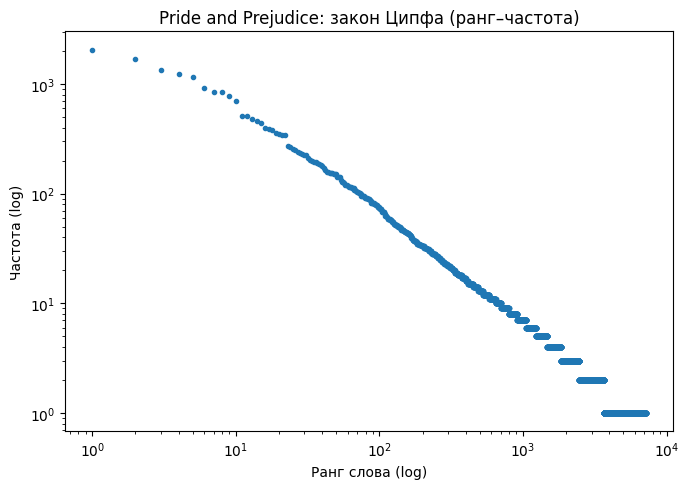

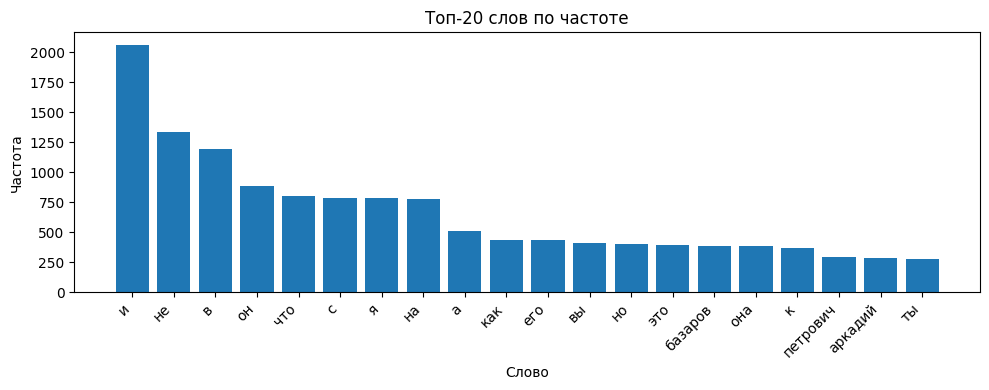

Хвост (c<=3): 5301 типов = 40.5% словаря
Хвост (c<=3): 7740 токенов = 14.2% текста


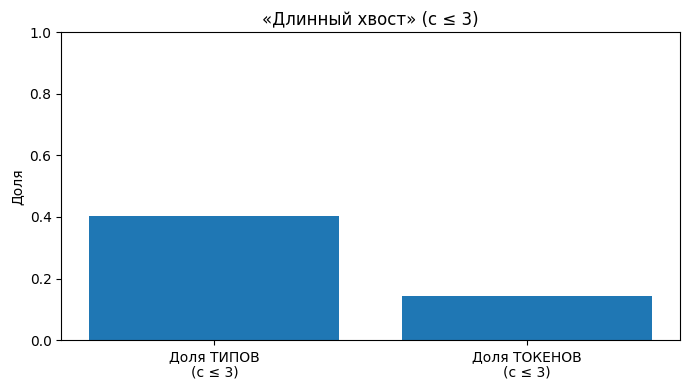

['галерея',
 'суета',
 'враждебный',
 'достаться',
 'заплата',
 'мещанин',
 'огорчение',
 'недопивать',
 'фотографический',
 'стройность']

In [6]:

# Zipf данные
freqs_sorted = np.array(sorted(cnt.values(), reverse=True))
ranks = np.arange(1, len(freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
plt.loglog(ranks, freqs_sorted, marker=".", linestyle="none")
plt.title("Pride and Prejudice: закон Ципфа (ранг–частота)")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

# 3.2 Топ-20
df_top20 = pd.DataFrame(top20, columns=["word","count"])
plt.figure(figsize=(10,4))
plt.bar(df_top20["word"], df_top20["count"])
plt.title("Топ-20 слов по частоте")
plt.xlabel("Слово")
plt.ylabel("Частота")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3.3 Длинный хвост: <= 3
tail_words = [w for w, c in cnt.items() if c <= 3]
tail_types = len(tail_words)
tail_tokens = sum(cnt[w] for w in tail_words)

print(f"Хвост (c<=3): {tail_types} типов = {tail_types/V_types:.1%} словаря")
print(f"Хвост (c<=3): {tail_tokens} токенов = {tail_tokens/N_tokens:.1%} текста")

plt.figure(figsize=(7,4))
plt.bar(["Доля ТИПОВ\n(c ≤ 3)", "Доля ТОКЕНОВ\n(c ≤ 3)"],
        [tail_types/V_types, tail_tokens/N_tokens])
plt.ylim(0, 1)
plt.title("«Длинный хвост» (c ≤ 3)")
plt.ylabel("Доля")
plt.tight_layout()
plt.show()

# 3.4 (Опционально) 10 случайных hapax (c=1)
hapax = [w for w, c in cnt.items() if c == 1]
rng = np.random.default_rng(0)
sample10 = list(rng.choice(hapax, size=10, replace=False))
sample10


## 5) Простая rule-based система: определение интентов

Сделаем игрушечный **intent detector** для пользовательских сообщений (на русском):
- greeting / goodbye
- ask_weather
- ask_time
- math_addition
- ask_name
- thanks
- other

Подход:
- регулярки + `spaCy Matcher`.

In [7]:
import re
import spacy
from spacy.matcher import Matcher

# Локальная русская токенизация для интентов (не переопределяем основной nlp)
nlp_intent = spacy.blank("ru")
matcher = Matcher(nlp_intent.vocab)

pattern_greet_1 = [{"LOWER": {"IN": ["привет", "здравствуйте", "здрасьте"]}}]
pattern_greet_2 = [{"LOWER": "добрый"}, {"LOWER": {"IN": ["день", "вечер"]}}]

pattern_goodbye_1 = [{"LOWER": {"IN": ["пока", "прощай"]}}]
pattern_goodbye_2 = [{"LOWER": "до"}, {"LOWER": "свидания"}]

pattern_weather = [{"LOWER": {"IN": ["погода", "дождь", "солнечно", "прогноз", "снег"]}}]
pattern_time_1 = [{"LOWER": {"IN": ["время", "час"]}}]
pattern_time_2 = [{"LOWER": "сколько"}, {"LOWER": "времени"}]

pattern_add_1 = [{"LOWER": {"IN": ["сложи", "сумма"]}}, {"IS_DIGIT": True}, {"LOWER": "и"}, {"IS_DIGIT": True}]
pattern_add_2 = [{"LOWER": "прибавь"}, {"IS_DIGIT": True}, {"LOWER": "к"}, {"IS_DIGIT": True}]
pattern_add_3 = [{"IS_DIGIT": True}, {"TEXT": "+"}, {"IS_DIGIT": True}]

# Новый интент через Matcher
pattern_name_1 = [{"LOWER": "как"}, {"LOWER": "тебя"}, {"LOWER": "зовут"}]
pattern_name_2 = [{"LOWER": "кто"}, {"LOWER": "ты"}]

matcher.add("GREET", [pattern_greet_1, pattern_greet_2])
matcher.add("GOODBYE", [pattern_goodbye_1, pattern_goodbye_2])
matcher.add("WEATHER", [pattern_weather])
matcher.add("TIME", [pattern_time_1, pattern_time_2])
matcher.add("ADD", [pattern_add_1, pattern_add_2, pattern_add_3])
matcher.add("ASK_NAME", [pattern_name_1, pattern_name_2])

# Новый интент через regex
thanks_re = re.compile(r"\b(спасибо|благодарю|спс)\b", re.IGNORECASE)

def detect_intent(text: str):
    doc = nlp_intent(text)
    matches = matcher(doc)
    labels = [nlp_intent.vocab.strings[m_id] for m_id, _, _ in matches]

    if "ADD" in labels:
        nums = [int(t.text) for t in doc if t.like_num]
        if len(nums) >= 2:
            return "math_addition", nums[0] + nums[1]
        return "math_addition", None
    if "WEATHER" in labels:
        return "ask_weather", None
    if "TIME" in labels:
        return "ask_time", None
    if "ASK_NAME" in labels:
        return "ask_name", None
    if thanks_re.search(text):
        return "thanks", None
    if "GREET" in labels:
        return "greeting", None
    if "GOODBYE" in labels:
        return "goodbye", None
    return "other", None

tests = [
    "Привет!",
    "Сложи 34957 и 70764",
    "Сколько будет 2 + 2?",
    "Какая погода завтра?",
    "Сколько сейчас времени?",
    "Как тебя зовут?",
    "Спасибо за помощь!",
    "До свидания!",
    "Объясни закон Ципфа в одном предложении."
]

for s in tests:
    intent, val = detect_intent(s)
    print(f"{s!r} -> {intent}", (f"(value={val})" if val is not None else ""))

'Привет!' -> greeting 
'Сложи 34957 и 70764' -> math_addition (value=105721)
'Сколько будет 2 + 2?' -> math_addition (value=4)
'Какая погода завтра?' -> ask_weather 
'Сколько сейчас времени?' -> other 
'Как тебя зовут?' -> ask_name 
'Спасибо за помощь!' -> thanks 
'До свидания!' -> goodbye 
'Объясни закон Ципфа в одном предложении.' -> other 


## 10) Мини-задача для семинара (русский)

1) Возьмите фрагмент русского романа (например, 30–100k символов).
2) Сравните частоты **по токенам**, **по стеммам**, **по леммам**:
   - Как меняются топ-20?
   - Как меняется доля “длинного хвоста” (≤3) по **types**?
3) Выберите 5 предложений и сравните:
   - POS/DEP/NER от `spaCy`
   - леммы от `pymorphy3`
4) Составьте список имен персонажей
5) Найдите как можно больше предложений, где здороваются


In [9]:
import spacy

nlp_ru = spacy.load("ru_core_news_sm")

doc_ru = nlp_ru(text)
print([(t.text, t.lemma_, t.pos_) for t in doc_ru[:10] if t.is_alpha])

[('Что', 'что', 'PRON'), ('Петр', 'пётр', 'PROPN'), ('не', 'не', 'PART'), ('видать', 'видать', 'VERB'), ('еще', 'ещё', 'ADV')]


In [10]:
sentences_5 = list(doc_ru.sents)[1:6]

# POS/DEP/NER от `spaCy`

In [11]:
rows = []
for sentence in sentences_5:
    for t in sentence:
        if t.is_space:
            continue
        rows.append([t.text, t.lemma_, t.pos_, t.tag_, t.morph.to_json()])
pd.DataFrame(rows, columns=["token","lemma","POS","TAG","morph"])

,token,lemma,POS,TAG,morph
0,--,--,PUNCT,PUNCT,
1,Что,что,PRON,PRON,Animacy=Inan|Case=Nom|Gender=Neut|Number=Sing
2,",",",",PUNCT,PUNCT,
3,Петр,пётр,PROPN,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing
4,",",",",PUNCT,PUNCT,
...,...,...,...,...,...
112,?,?,PUNCT,PUNCT,
113,--,--,PUNCT,PUNCT,
114,повторил,повторить,VERB,VERB,Aspect=Perf|Gender=Masc|Mood=Ind|Number=Sing|T...
115,барин,барин,PROPN,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing


# Леммы 

In [13]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()



for ru_tokens in sentences_5:
    ru_tokens = [t.text for t in ru_tokens if t.is_alpha]
    ru_lemmas_pym = [morph.parse(w)[0].normal_form for w in ru_tokens]
    print(list(zip(ru_tokens, ru_lemmas_pym)))


[('Что', 'что'), ('Петр', 'пётр'), ('не', 'не'), ('видать', 'видать'), ('еще', 'ещё')]
[('спрашивал', 'спрашивать'), ('мая', 'май'), ('года', 'год'), ('выходя', 'выходить'), ('без', 'без'), ('шапки', 'шапка'), ('на', 'на'), ('низкое', 'низкий'), ('крылечко', 'крылечко'), ('постоялого', 'постоялое'), ('двора', 'двор'), ('на', 'на'), ('шоссе', 'шоссе'), ('барин', 'барин'), ('лет', 'год'), ('сорока', 'сорок'), ('с', 'с'), ('небольшим', 'небольшой'), ('в', 'в'), ('запыленном', 'запылить'), ('пальто', 'пальто'), ('и', 'и'), ('клетчатых', 'клетчатый'), ('панталонах', 'панталоны'), ('у', 'у'), ('своего', 'свой'), ('слуги', 'слуга'), ('молодого', 'молодой'), ('и', 'и'), ('щекастого', 'щекастый'), ('малого', 'малое'), ('с', 'с'), ('беловатым', 'беловатый'), ('пухом', 'пух'), ('на', 'на'), ('подбородке', 'подбородок'), ('и', 'и'), ('маленькими', 'маленький'), ('тусклыми', 'тусклый'), ('глазенками', 'глазёнки')]
[('Слуга', 'слуга'), ('в', 'в'), ('котором', 'который'), ('все', 'всё'), ('и', 'и'), 

## Поиск имён персонажей

In [ ]:
from collections import Counter
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

text = re.sub(r"\s+", " ", text).strip()
doc_full = nlp_ru(text[:120000])

persons = []
for ent in doc_full.ents:
    if ent.label_ == "PER":
        parts = []
        for w in ent.text.split():
            w_clean = ''.join(ch for ch in w if ch.isalpha() or ch in '-').strip('-')
            if not w_clean:
                continue
            parts.append(morph.parse(w_clean)[0].normal_form)
        if parts:
            persons.append(' '.join(parts))

person_counts = Counter(persons)
pd.DataFrame(person_counts.most_common(30), columns=["character", "count"]) 

,character,count
0,николай петрович,117
1,аркадий,112
2,базар,100
3,павел петрович,97
4,фенёчек,31
5,базаров,24
6,ситниковый,22
7,пётр,11
8,дуняша,11
9,матвей ильич,10


## Поиск предложений, где здороваются (regex)

In [ ]:
import re

greet_patterns = [
    r"\bпривет\b",
    r"\bздравствуй(?:те)?\b",
    r"\bдобр(?:ый|ое)\s+(?:день|вечер|утро)\b",
    r"\bздорово\b",
    r"\bсалют\b",
    r"\bпоздоровал(?:ся|ась|ись)?\b",
    r"\bпоздоровавш(?:ий|ая|ее|ие)\b",
    r"\bпоприветствовал(?:а|и)?\b",
]
greet_re = re.compile('|'.join(greet_patterns), flags=re.IGNORECASE)

greet_sents = []
for s in doc_full.sents:
    st = s.text.strip()
    if greet_re.search(st):
        greet_sents.append(st)

print(f"Найдено предложений с приветствием: {len(greet_sents)}")
print("\nПервые 20 примеров:\n")
for i, s in enumerate(greet_sents[:20], 1):
    print(f"{i:02d}. {s}")

Найдено предложений с приветствием: 8

Первые 20 примеров:

01. -- Здравствуй, Фенечка, -- проговорил он сквозь зубы.
02. -- Здравствуйте-с, -- ответила она негромким, но звучным голосом и, глянув искоса на Аркадия, который дружелюбно ей улыбался, тихонько вышла.
03. Он быстро приблизился к террасе и, качнув головою, промолвил: -- Здравствуйте, господа извините, что опоздал к чаю, сейчас вернусь надо вот этих пленниц к месту пристроить.
04. Здравствуй, пузырь, -- проговорил он с внезапным оживлением и, приблизившись к ребенку, поцеловал его в щеку потом он нагнулся немного и приложил губы к Фенечкиной руке, белевшей, как молоко, на красной рубашечке Мити.
05. Он увидал ее головку сквозь золотую сетку колосьев, откуда она высматривала, как зверок, и ласково крикнул ей: -- Здравствуй, Фенечка!
06. -- Здравствуйте, -- прошептала она, не выходя из своей засады.
07. Павел Петрович отрывисто сказал ему: {добрый вечер(франц.).
08. Она встала с дивана и, небрежно натягивая себе на плечи бархат